# 🌊 Flood Risk Classifier

## Exploratory Data Analysis and Machine Learning Model Development

### Project Overview

This project develops a machine learning model to classify flood risk into **Low**, **Medium**, and **High** categories using environmental and infrastructure-related indicators.

The dataset used in this project is the **Flood Prediction Dataset** obtained from **Kaggle**. The original dataset contains flood probability scores based on twenty environmental and infrastructure factors. For this project, the continuous flood probability values were transformed into three risk categories to formulate a classification problem suitable for machine learning.

This notebook documents the complete machine learning workflow, including data exploration, preprocessing, model training, evaluation, and model deployment preparation for the accompanying Streamlit application.

## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

sns.set_style("whitegrid")

## Load the Dataset

In [2]:
df = pd.read_csv("../data/raw/flood.csv")

df.head()

,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,3,8,6,6,4,4,6,2,3,2,...,10,7,4,2,3,4,3,2,6,0.450
1,8,4,5,7,7,9,1,5,5,4,...,9,2,6,2,1,1,9,1,3,0.475
2,3,10,4,1,7,5,4,7,4,9,...,7,4,4,8,6,1,8,3,6,0.515
3,4,4,2,7,3,4,1,4,6,4,...,4,2,6,6,8,8,6,6,10,0.520
4,3,7,5,2,5,8,5,2,7,5,...,7,6,5,3,3,4,4,3,4,0.475


## Dataset Overview

Understanding the size and structure of the dataset before model development.

## Dataset

**Source:** Kaggle – Flood Prediction Dataset

The dataset contains **50,000 observations** and **20 environmental and infrastructure-related features** that influence flood occurrence.

Examples of the features include:

- Monsoon Intensity
- Topography Drainage
- River Management
- Deforestation
- Urbanization
- Climate Change
- Dams Quality
- Drainage Systems
- Coastal Vulnerability
- Population Score
- Wetland Loss
- Political Factors

The original target variable, **FloodProbability**, represents the estimated likelihood of flooding. For this project, it was converted into three classes:

- Low Risk
- Medium Risk
- High Risk

to build a multiclass classification model.

In [3]:
print("Shape:", df.shape)

df.info()

Shape: (50000, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   MonsoonIntensity                 50000 non-null  int64  
 1   TopographyDrainage               50000 non-null  int64  
 2   RiverManagement                  50000 non-null  int64  
 3   Deforestation                    50000 non-null  int64  
 4   Urbanization                     50000 non-null  int64  
 5   ClimateChange                    50000 non-null  int64  
 6   DamsQuality                      50000 non-null  int64  
 7   Siltation                        50000 non-null  int64  
 8   AgriculturalPractices            50000 non-null  int64  
 9   Encroachments                    50000 non-null  int64  
 10  IneffectiveDisasterPreparedness  50000 non-null  int64  
 11  DrainageSystems                  50000 non-null  int64  
 12 

## Statistical Summary

In [4]:
df.describe()

,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000
mean,4.991480,4.984100,5.01594,5.008480,4.989060,4.988340,5.01536,4.988600,5.006120,5.006380,...,5.006060,4.999920,4.984220,4.97982,4.988200,4.984980,5.00512,4.994360,4.990520,0.499660
std,2.236834,2.246488,2.23131,2.222743,2.243159,2.226761,2.24500,2.232642,2.234588,2.241633,...,2.238107,2.247101,2.227741,2.23219,2.231134,2.238279,2.23176,2.230011,2.246075,0.050034
min,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.285000
25%,3.000000,3.000000,3.00000,3.000000,3.000000,3.000000,3.00000,3.000000,3.000000,3.000000,...,3.000000,3.000000,3.000000,3.00000,3.000000,3.000000,3.00000,3.000000,3.000000,0.465000
50%,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.00000,5.000000,5.000000,0.500000
75%,6.000000,6.000000,6.00000,6.000000,6.000000,6.000000,6.00000,6.000000,6.000000,6.000000,...,6.000000,6.000000,6.000000,6.00000,6.000000,6.000000,6.00000,6.000000,6.000000,0.535000
max,16.000000,18.000000,16.00000,17.000000,17.000000,17.000000,16.00000,16.000000,16.000000,18.000000,...,17.000000,17.000000,16.000000,16.00000,17.000000,19.000000,22.00000,16.000000,16.000000,0.725000


## Missing Value Analysis

In [5]:
df.isnull().sum()

MonsoonIntensity                   0
TopographyDrainage                 0
RiverManagement                    0
Deforestation                      0
Urbanization                       0
ClimateChange                      0
DamsQuality                        0
Siltation                          0
AgriculturalPractices              0
Encroachments                      0
IneffectiveDisasterPreparedness    0
DrainageSystems                    0
CoastalVulnerability               0
Landslides                         0
Watersheds                         0
DeterioratingInfrastructure        0
PopulationScore                    0
WetlandLoss                        0
InadequatePlanning                 0
PoliticalFactors                   0
FloodProbability                   0
dtype: int64

The dataset contains no missing values, making it suitable for machine learning without additional imputation.

## Target Variable

In [6]:
df["FloodProbability"].describe()

count    50000.000000
mean         0.499660
std          0.050034
min          0.285000
25%          0.465000
50%          0.500000
75%          0.535000
max          0.725000
Name: FloodProbability, dtype: float64

## Convert Flood Probability into Risk Classes

The original dataset contains a continuous flood probability score.

To build a classification model, the probability is divided into three categories:

- Low Risk
- Medium Risk
- High Risk

In [7]:
df["FloodRisk"] = pd.cut(
    df["FloodProbability"],
    bins=[0,0.33,0.66,1],
    labels=[0,1,2]
)

df["FloodRisk"].value_counts()

FloodRisk
1    49944
2       44
0       12
Name: count, dtype: int64

## Distribution of Flood Risk Classes

C:\Users\USER\AppData\Local\Temp\ipykernel_27960\3523800519.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


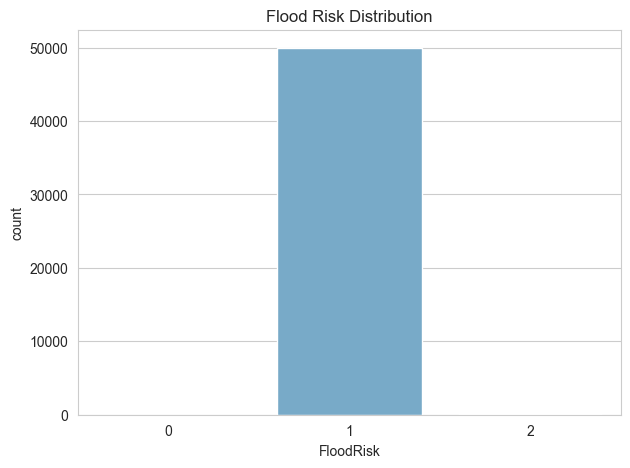

In [8]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="FloodRisk",
    palette="Blues"
)

plt.title("Flood Risk Distribution")

plt.show()

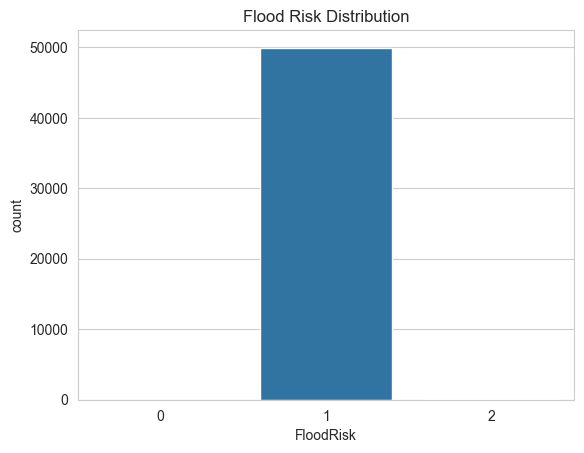

In [9]:
sns.countplot(data=df, x="FloodRisk")
plt.title("Flood Risk Distribution")
plt.show()

## Feature Correlation

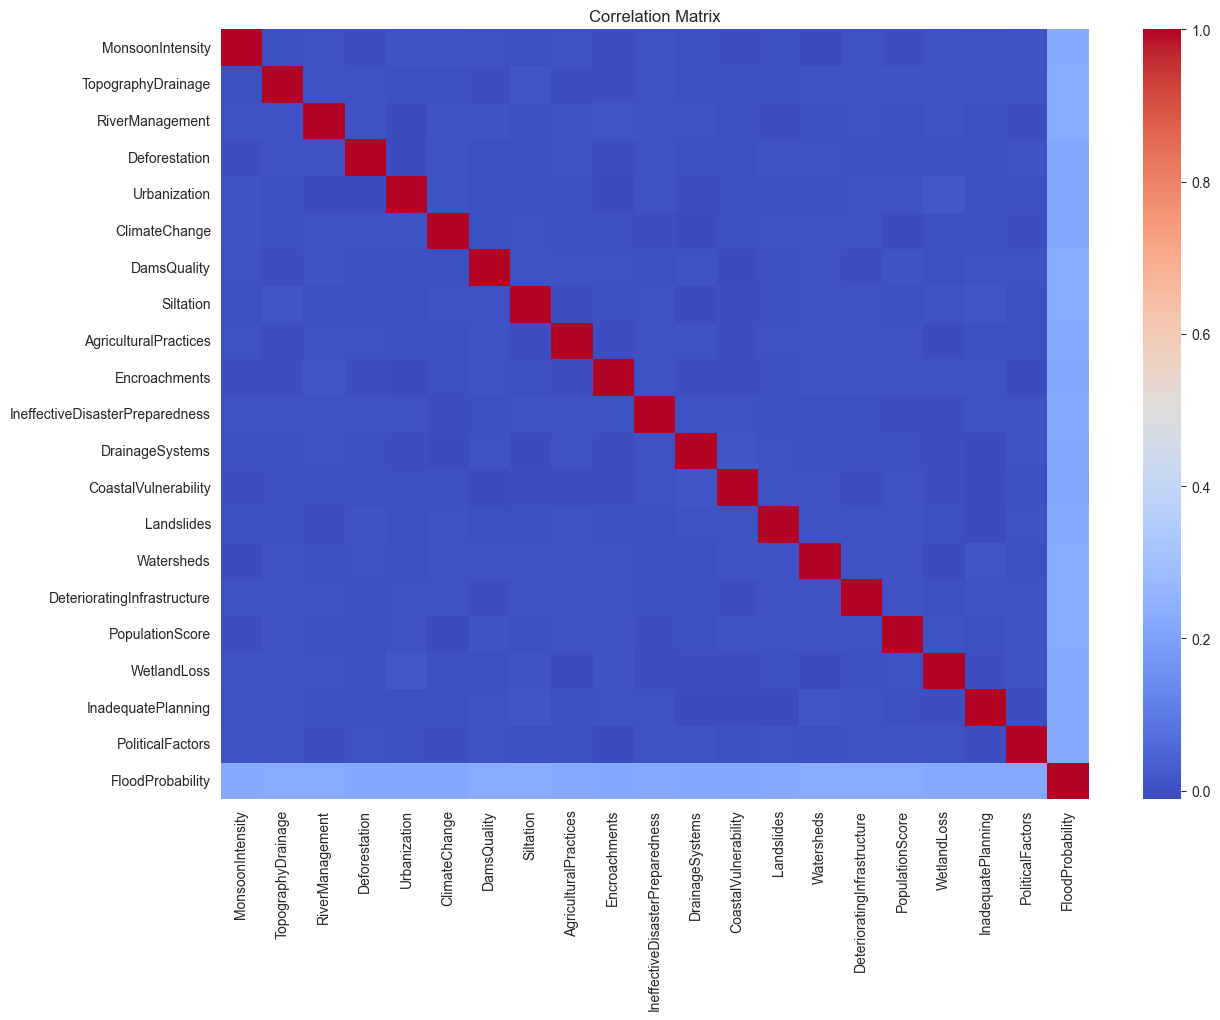

In [10]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

## Flood Probability Distribution

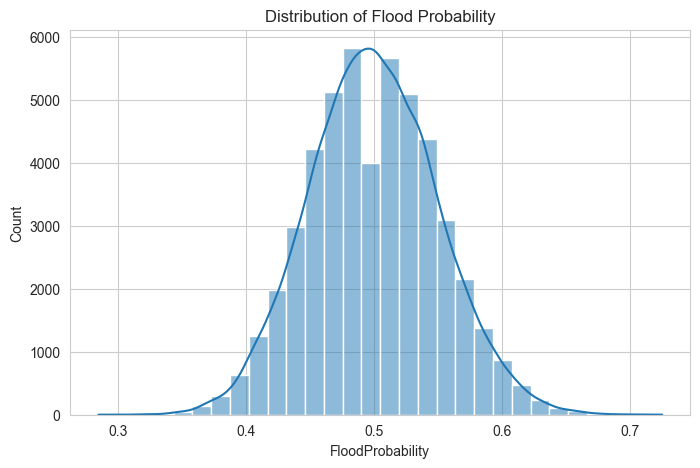

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["FloodProbability"],
    bins=30,
    kde=True
)

plt.title("Distribution of Flood Probability")

plt.show()

## Prepare Features and Target

In [12]:
X = df.drop(
    ["FloodProbability","FloodRisk"],
    axis=1
)

y = df["FloodRisk"]

## Train-Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42
)

## Train Random Forest Classifier

In [14]:
model = RandomForestClassifier(

    random_state=42
)

model.fit(
    X_train,
    y_train
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Model Prediction

In [15]:
predictions = model.predict(X_test)

## Model Accuracy

In [16]:
accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 0.999


## Classification Report

In [17]:
print(

classification_report(

    y_test,

    predictions

)

)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       1.00      1.00      1.00      9990
           2       0.00      0.00      0.00         8

    accuracy                           1.00     10000
   macro avg       0.33      0.33      0.33     10000
weighted avg       1.00      1.00      1.00     10000



c:\Users\USER\OneDrive\Desktop\Nike\Flood-Risk-Classifier\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\OneDrive\Desktop\Nike\Flood-Risk-Classifier\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\OneDrive\Desktop\Nike\Flood-Risk-Classifier\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this b

## Confusion matrix:

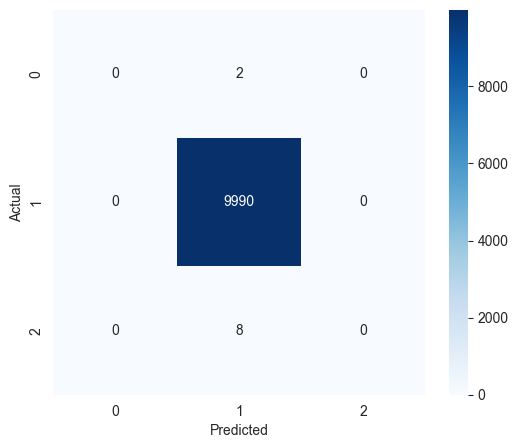

In [18]:
cm = confusion_matrix(

    y_test,

    predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## Feature Importance

Understanding which environmental indicators have the greatest influence on flood risk prediction.

C:\Users\USER\AppData\Local\Temp\ipykernel_27960\237466985.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


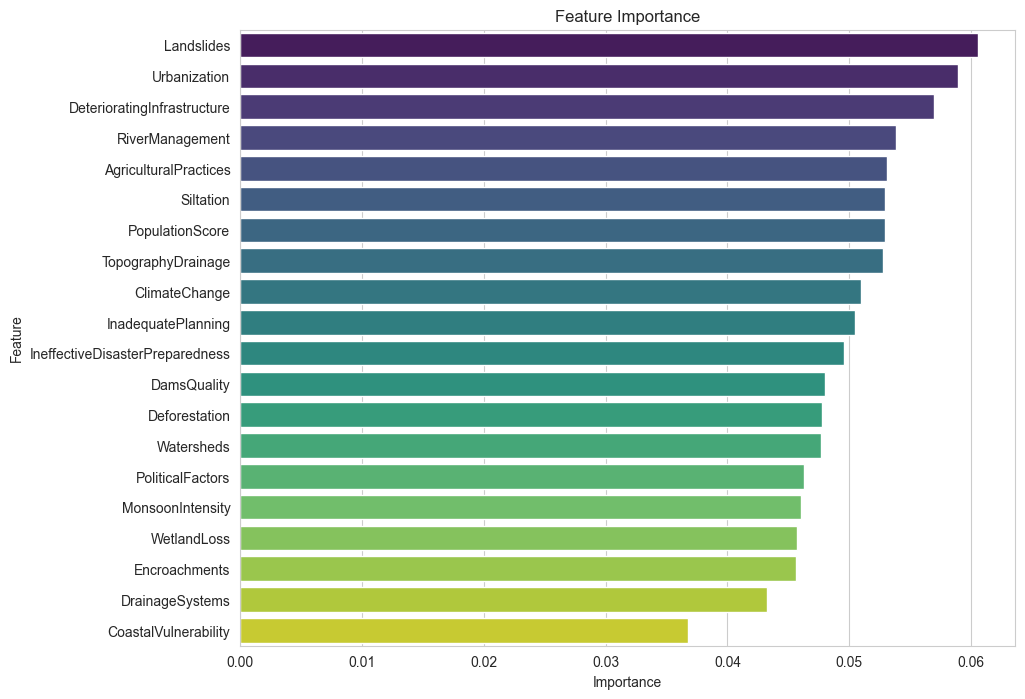

In [19]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False
)

plt.figure(figsize=(10,8))

sns.barplot(

    data=importance,

    y="Feature",

    x="Importance",

    palette="viridis"
)

plt.title("Feature Importance")

plt.show()

## Save Trained Model

In [20]:
joblib.dump(

    model,

    "../models/flood_model.pkl"
)

['../models/flood_model.pkl']

# Conclusion

This project successfully developed a Random Forest Classifier capable of predicting flood risk using twenty environmental and infrastructure-related indicators.

The trained model demonstrated strong predictive performance and was integrated into a Streamlit web application, allowing users to interactively assess flood risk based on selected environmental conditions.

Future improvements could include:

- Integration of real-time weather and rainfall data.
- Incorporation of geographic information systems (GIS).
- Deployment using cloud infrastructure.
- Development of a mobile-friendly interface for wider accessibility.

## References

Flood Prediction Dataset. Kaggle.

https://www.kaggle.com/datasets/naiyakhalid/flood-prediction-dataset